# AEGES-Q: UNSW-NB15 QML Benchmark

## Objective

This notebook evaluates quantum machine-learning approaches for binary network intrusion detection using the UNSW-NB15 dataset.

The objective is to compare QML classification performance against the established classical Random Forest baseline under a consistent experimental setup.

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- False Positive Rate (FPR)
- Training time
- Inference time

### Experimental Principle

The classical IDS pipeline has already been completed and is treated as the baseline.

The QML experiments use the same underlying UNSW-NB15 train/test split while constructing a quantum-compatible feature representation.

All experiments are performed locally using Qiskit Aer simulation.

## 1. Experimental Setup

In [18]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    mean_squared_error,
)

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Project root
PROJECT_ROOT = Path.cwd().parent.parent

print("Project root:", PROJECT_ROOT)
print("Python environment ready.")

Project root: c:\Projects\Aeges-Q
Python environment ready.


## 2. Load the UNSW-NB15 Dataset

The original author-provided training and testing split is retained:

- Training set: 82,332 samples
- Testing set: 175,341 samples

The existing classical preprocessing pipeline is not modified.

In [2]:
TRAIN_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "UNSW_NB15_training-set.csv"
)

TEST_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "UNSW_NB15_testing-set.csv"
)

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nTarget distribution:")
print(train_df["label"].value_counts().sort_index())

Training shape: (82332, 45)
Testing shape: (175341, 45)

Training columns:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

Target distribution:
label
0    37000
1    45332
Name: count, dtype: int64


## 3. Load Existing Classical Preprocessing

In [4]:
import joblib

PREPROCESSOR_PATH = (
    PROJECT_ROOT
    / "artifacts"
    / "classical"
    / "variant_e_preprocessor.joblib"
)

preprocessor = joblib.load(PREPROCESSOR_PATH)

print("Loaded preprocessor:", type(preprocessor).__name__)
print("Transformed feature count:", len(preprocessor.get_feature_names_out()))

Loaded preprocessor: ColumnTransformer
Transformed feature count: 177


In [5]:
X_train_full = preprocessor.transform(
    train_df.drop(columns=["label"])
)

X_test_full = preprocessor.transform(
    test_df.drop(columns=["label"])
)

y_train_full = train_df["label"].to_numpy()
y_test_full = test_df["label"].to_numpy()

print("Processed training shape:", X_train_full.shape)
print("Processed testing shape:", X_test_full.shape)

Processed training shape: (82332, 177)
Processed testing shape: (175341, 177)


## 4. Quantum-Compatible Feature Reduction

The classical preprocessing pipeline produces 177 transformed features.

To make quantum simulation computationally practical, the transformed feature space is compressed into a small number of components using PCA.

Four principal components are used initially, corresponding to a four-qubit quantum feature map.

PCA is fitted only on the training data to prevent test-set information leakage.

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# Convert sparse matrices if necessary
if hasattr(X_train_full, "toarray"):
    X_train_dense = X_train_full.toarray()
    X_test_dense = X_test_full.toarray()
else:
    X_train_dense = np.asarray(X_train_full)
    X_test_dense = np.asarray(X_test_full)

# PCA -> 4 quantum-compatible features
pca = PCA(
    n_components=4,
    random_state=RANDOM_STATE
)

X_train_pca = pca.fit_transform(X_train_dense)
X_test_pca = pca.transform(X_test_dense)

print("PCA training shape:", X_train_pca.shape)
print("PCA testing shape:", X_test_pca.shape)

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

PCA training shape: (82332, 4)
PCA testing shape: (175341, 4)
Explained variance ratio: [0.23131599 0.09122509 0.0777905  0.05604421]
Total explained variance: 0.45637578514427934


## 4.1 Encode PCA Features as Quantum Rotation Angles

In [7]:
# Scale PCA components using training data only
pca_scaler = MinMaxScaler(feature_range=(0, 1))

X_train_quantum = pca_scaler.fit_transform(X_train_pca)
X_test_quantum = pca_scaler.transform(X_test_pca)

# Map [0, 1] -> [0, pi]
X_train_angles = X_train_quantum * np.pi
X_test_angles = X_test_quantum * np.pi

print("Quantum training shape:", X_train_angles.shape)
print("Quantum testing shape:", X_test_angles.shape)

print("\nFirst encoded training sample:")
print(X_train_angles[0])

Quantum training shape: (82332, 4)
Quantum testing shape: (175341, 4)

First encoded training sample:
[0.61541876 1.33658505 0.33038435 0.6175476 ]


## 5. Quantum Circuit Candidates

Three variational quantum classifier architectures are evaluated:

- **Circuit A:** Feature encoding only
- **Circuit B:** Feature encoding + trainable rotation layer
- **Circuit C:** Feature encoding + trainable rotations + entanglement

All circuits use four qubits and the same four PCA-derived quantum features.

The objective is to determine whether additional trainable layers and qubit entanglement improve binary intrusion classification.

In [8]:
from qiskit.circuit import ParameterVector

N_QUBITS = 4

# Separate trainable parameters for each architecture
theta_b = ParameterVector("θB", length=4)
theta_c = ParameterVector("θC", length=8)


def build_circuit_a(features):
    """Circuit A: feature encoding only."""
    qc = QuantumCircuit(N_QUBITS, 1)

    for q in range(N_QUBITS):
        qc.ry(float(features[q]), q)

    qc.measure(0, 0)

    return qc


def build_circuit_b(features):
    """Circuit B: feature encoding + trainable rotations."""
    qc = QuantumCircuit(N_QUBITS, 1)

    # Feature encoding
    for q in range(N_QUBITS):
        qc.ry(float(features[q]), q)

    # Trainable layer
    for q in range(N_QUBITS):
        qc.ry(theta_b[q], q)

    qc.measure(0, 0)

    return qc


def build_circuit_c(features):
    """Circuit C: feature encoding + trainable rotations + entanglement."""
    qc = QuantumCircuit(N_QUBITS, 1)

    # Feature encoding
    for q in range(N_QUBITS):
        qc.ry(float(features[q]), q)

    # Trainable rotation layer
    for q in range(N_QUBITS):
        qc.ry(theta_c[q], q)

    # Entanglement
    for q in range(N_QUBITS - 1):
        qc.cx(q, q + 1)

    # Second trainable layer
    for q in range(N_QUBITS):
        qc.rz(theta_c[q + 4], q)

    qc.measure(0, 0)

    return qc

In [9]:
# Use one real dataset sample
example_features = X_train_angles[0]

circuit_a = build_circuit_a(example_features)
circuit_b = build_circuit_b(example_features)
circuit_c = build_circuit_c(example_features)

print("Circuit A:")
print(circuit_a)

print("\nCircuit B:")
print(circuit_b)

print("\nCircuit C:")
print(circuit_c)

Circuit A:
     ┌─────────────┐┌─┐
q_0: ┤ Ry(0.61542) ├┤M├
     └┬────────────┤└╥┘
q_1: ─┤ Ry(1.3366) ├─╫─
     ┌┴────────────┤ ║ 
q_2: ┤ Ry(0.33038) ├─╫─
     ├─────────────┤ ║ 
q_3: ┤ Ry(0.61755) ├─╫─
     └─────────────┘ ║ 
c: 1/════════════════╩═
                     0 

Circuit B:
     ┌─────────────┐┌───────────┐┌─┐
q_0: ┤ Ry(0.61542) ├┤ Ry(θB[0]) ├┤M├
     └┬────────────┤├───────────┤└╥┘
q_1: ─┤ Ry(1.3366) ├┤ Ry(θB[1]) ├─╫─
     ┌┴────────────┤├───────────┤ ║ 
q_2: ┤ Ry(0.33038) ├┤ Ry(θB[2]) ├─╫─
     ├─────────────┤├───────────┤ ║ 
q_3: ┤ Ry(0.61755) ├┤ Ry(θB[3]) ├─╫─
     └─────────────┘└───────────┘ ║ 
c: 1/═════════════════════════════╩═
                                  0 

Circuit C:
     ┌─────────────┐┌───────────┐     ┌───────────┐             ┌─┐»
q_0: ┤ Ry(0.61542) ├┤ Ry(θC[0]) ├──■──┤ Rz(θC[4]) ├─────────────┤M├»
     └┬────────────┤├───────────┤┌─┴─┐└───────────┘┌───────────┐└╥┘»
q_1: ─┤ Ry(1.3366) ├┤ Ry(θC[1]) ├┤ X ├──────■──────┤ Rz(θC[5]) ├─╫─»
     ┌┴───────────

## 6. Create the QML Benchmark Subset

To compare circuit architectures efficiently on the local simulator, a stratified subset is used for the initial benchmark.

The same subset is used for all candidate circuits to ensure a fair comparison.

The full UNSW-NB15 datasets remain unchanged and will be used for the final evaluation of the selected model.

In [13]:
from sklearn.model_selection import train_test_split

BENCHMARK_TRAIN_SIZE = 500
BENCHMARK_TEST_SIZE = 500

# Stratified benchmark training set
X_bench_train, _, y_bench_train, _ = train_test_split(
    X_train_angles,
    y_train_full,
    train_size=BENCHMARK_TRAIN_SIZE,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

# Stratified benchmark test set
X_bench_test, _, y_bench_test, _ = train_test_split(
    X_test_angles,
    y_test_full,
    train_size=BENCHMARK_TEST_SIZE,
    stratify=y_test_full,
    random_state=RANDOM_STATE
)

print("Benchmark training:", X_bench_train.shape)
print("Benchmark testing:", X_bench_test.shape)

Benchmark training: (500, 4)
Benchmark testing: (500, 4)


## 7. Quantum Circuit Evaluation Functions

In [14]:
from qiskit_aer import AerSimulator

simulator = AerSimulator()

print("Aer simulator initialized:", simulator)

Aer simulator initialized: AerSimulator('aer_simulator')


In [15]:
def run_quantum_probability(circuit, parameters=None, shots=256):
    """
    Execute a parameterized or fixed circuit and return
    the probability of measuring the output qubit as 1.
    """
    if parameters is not None:
        circuit = circuit.assign_parameters(parameters)

    result = simulator.run(
        circuit,
        shots=shots
    ).result()

    counts = result.get_counts()

    total = sum(counts.values())
    ones = counts.get("1", 0)

    return ones / total


def evaluate_circuit(
    circuit_builder,
    X_data,
    parameters=None,
    shots=256
):
    """
    Evaluate a circuit across a dataset.
    """
    probabilities = []

    for sample in X_data:
        circuit = circuit_builder(sample)

        probability = run_quantum_probability(
            circuit,
            parameters=parameters,
            shots=shots
        )

        probabilities.append(probability)

    return np.array(probabilities)

In [16]:
start_time = time.time()

circuit_a_probabilities = evaluate_circuit(
    build_circuit_a,
    X_bench_test,
    shots=256
)

circuit_a_time = time.time() - start_time

circuit_a_predictions = (
    circuit_a_probabilities >= 0.5
).astype(int)

circuit_a_accuracy = accuracy_score(
    y_bench_test,
    circuit_a_predictions
)

circuit_a_f1 = f1_score(
    y_bench_test,
    circuit_a_predictions,
    zero_division=0
)

circuit_a_auc = roc_auc_score(
    y_bench_test,
    circuit_a_probabilities
)

print(f"Circuit A evaluation time: {circuit_a_time:.2f}s")
print(f"Accuracy: {circuit_a_accuracy:.4f}")
print(f"F1-score: {circuit_a_f1:.4f}")
print(f"ROC-AUC: {circuit_a_auc:.4f}")

Circuit A evaluation time: 2.15s
Accuracy: 0.3200
F1-score: 0.0000
ROC-AUC: 0.2613


## 8. Benchmark Trainable Circuit B

Circuit B extends the basic feature-encoding circuit with a trainable single-qubit rotation layer.

Unlike Circuit A, Circuit B contains trainable parameters that can be optimized using the intrusion-detection training data.

The same benchmark training subset and evaluation procedure are used to maintain a fair comparison between circuit architectures.

In [19]:
# Initial parameters for Circuit B
theta_b_values = np.array([
    0.1, 0.2, 0.3, 0.4
], dtype=float)


def circuit_b_parameters(values):
    return {
        theta_b[i]: float(values[i])
        for i in range(4)
    }


def circuit_b_loss(values, X_data, y_data, shots=128):
    parameters = circuit_b_parameters(values)

    probabilities = evaluate_circuit(
        build_circuit_b,
        X_data,
        parameters=parameters,
        shots=shots
    )

    return mean_squared_error(y_data, probabilities)


print(
    "Initial Circuit B loss:",
    circuit_b_loss(
        theta_b_values,
        X_bench_train,
        y_bench_train
    )
)

Initial Circuit B loss: 0.4274459228515625


In [20]:
def train_circuit_b(
    initial_values,
    X_data,
    y_data,
    iterations=15,
    learning_rate=0.15,
    perturbation=0.10,
    shots=128
):
    values = initial_values.copy()
    history = []

    for iteration in range(iterations):

        direction = np.random.choice(
            [-1, 1],
            size=len(values)
        )

        plus_values = (
            values + perturbation * direction
        )

        minus_values = (
            values - perturbation * direction
        )

        plus_loss = circuit_b_loss(
            plus_values,
            X_data,
            y_data,
            shots
        )

        minus_loss = circuit_b_loss(
            minus_values,
            X_data,
            y_data,
            shots
        )

        gradient = (
            (plus_loss - minus_loss)
            / (2 * perturbation)
        ) * direction

        values -= learning_rate * gradient

        current_loss = circuit_b_loss(
            values,
            X_data,
            y_data,
            shots
        )

        history.append(current_loss)

        print(
            f"Iteration {iteration + 1:02d}/{iterations} "
            f"| Loss: {current_loss:.6f}"
        )

    return values, history

In [21]:
start_time = time.time()

trained_b_values, b_history = train_circuit_b(
    theta_b_values,
    X_bench_train,
    y_bench_train
)

circuit_b_training_time = time.time() - start_time

print(
    f"\nCircuit B training time: "
    f"{circuit_b_training_time:.2f}s"
)

print("Trained parameters:")
print(trained_b_values)

Iteration 01/15 | Loss: 0.417814
Iteration 02/15 | Loss: 0.413220
Iteration 03/15 | Loss: 0.407181
Iteration 04/15 | Loss: 0.398214
Iteration 05/15 | Loss: 0.389798
Iteration 06/15 | Loss: 0.388035
Iteration 07/15 | Loss: 0.382972
Iteration 08/15 | Loss: 0.374887
Iteration 09/15 | Loss: 0.373639
Iteration 10/15 | Loss: 0.369840
Iteration 11/15 | Loss: 0.369221
Iteration 12/15 | Loss: 0.360379
Iteration 13/15 | Loss: 0.355878
Iteration 14/15 | Loss: 0.353234
Iteration 15/15 | Loss: 0.350833

Circuit B training time: 91.55s
Trained parameters:
[0.50018149 0.23112619 0.41352859 0.41315311]


In [22]:
trained_b_parameters = circuit_b_parameters(
    trained_b_values
)

start_time = time.time()

circuit_b_probabilities = evaluate_circuit(
    build_circuit_b,
    X_bench_test,
    parameters=trained_b_parameters,
    shots=256
)

circuit_b_inference_time = time.time() - start_time

circuit_b_predictions = (
    circuit_b_probabilities >= 0.5
).astype(int)

print(f"Inference time: {circuit_b_inference_time:.2f}s")
print(
    f"Accuracy: "
    f"{accuracy_score(y_bench_test, circuit_b_predictions):.4f}"
)
print(
    f"Precision: "
    f"{precision_score(y_bench_test, circuit_b_predictions, zero_division=0):.4f}"
)
print(
    f"Recall: "
    f"{recall_score(y_bench_test, circuit_b_predictions, zero_division=0):.4f}"
)
print(
    f"F1: "
    f"{f1_score(y_bench_test, circuit_b_predictions, zero_division=0):.4f}"
)
print(
    f"ROC-AUC: "
    f"{roc_auc_score(y_bench_test, circuit_b_probabilities):.4f}"
)

Inference time: 2.37s
Accuracy: 0.3640
Precision: 0.6310
Recall: 0.1559
F1: 0.2500
ROC-AUC: 0.2660


## 8.1 Circuit B Results

Circuit B reduced the training loss from approximately 0.4274 to 0.3508 over 15 SPSA iterations.

However, its test performance remained poor, with an accuracy of 36.4%, F1-score of 0.25, and ROC-AUC of 0.2660.

The low ROC-AUC indicates that the learned output probability does not provide useful separation between normal and attack traffic.

Therefore, Circuit B is not selected as the final QML classifier. The result motivates testing an entangling architecture in Circuit C.

## 9. Benchmark Trainable Circuit C

Circuit C extends Circuit B by introducing an entanglement layer between adjacent qubits.

The circuit contains:

- Four feature-encoding rotations
- Four trainable Y-rotation parameters
- Three CNOT entangling gates
- Four additional trainable Z-rotation parameters

The same benchmark dataset, optimizer settings, and measurement shots used for Circuit B are retained for a fair comparison.

In [23]:
# Circuit C has 8 trainable parameters
theta_c_values = np.array([
    0.1, 0.2, 0.3, 0.4,
    0.1, 0.2, 0.3, 0.4
], dtype=float)


def circuit_c_parameters(values):
    return {
        theta_c[i]: float(values[i])
        for i in range(8)
    }


def circuit_c_loss(values, X_data, y_data, shots=128):
    parameters = circuit_c_parameters(values)

    probabilities = evaluate_circuit(
        build_circuit_c,
        X_data,
        parameters=parameters,
        shots=shots
    )

    return mean_squared_error(
        y_data,
        probabilities
    )


initial_c_loss = circuit_c_loss(
    theta_c_values,
    X_bench_train,
    y_bench_train
)

print(f"Initial Circuit C loss: {initial_c_loss:.6f}")

Initial Circuit C loss: 0.425234


In [24]:
def train_circuit_c(
    initial_values,
    X_data,
    y_data,
    iterations=15,
    learning_rate=0.15,
    perturbation=0.10,
    shots=128
):
    values = initial_values.copy()
    history = []

    for iteration in range(iterations):

        direction = np.random.choice(
            [-1, 1],
            size=len(values)
        )

        plus_values = (
            values + perturbation * direction
        )

        minus_values = (
            values - perturbation * direction
        )

        plus_loss = circuit_c_loss(
            plus_values,
            X_data,
            y_data,
            shots
        )

        minus_loss = circuit_c_loss(
            minus_values,
            X_data,
            y_data,
            shots
        )

        gradient = (
            (plus_loss - minus_loss)
            / (2 * perturbation)
        ) * direction

        values -= learning_rate * gradient

        current_loss = circuit_c_loss(
            values,
            X_data,
            y_data,
            shots
        )

        history.append(current_loss)

        print(
            f"Iteration {iteration + 1:02d}/{iterations} "
            f"| Loss: {current_loss:.6f}"
        )

    return values, history

In [25]:
start_time = time.time()

trained_c_values, c_history = train_circuit_c(
    theta_c_values,
    X_bench_train,
    y_bench_train,
    iterations=15,
    learning_rate=0.15,
    perturbation=0.10,
    shots=128
)

circuit_c_training_time = time.time() - start_time

print(
    f"\nCircuit C training time: "
    f"{circuit_c_training_time:.2f}s"
)

print("Trained parameters:")
print(trained_c_values)

Iteration 01/15 | Loss: 0.418438
Iteration 02/15 | Loss: 0.416321
Iteration 03/15 | Loss: 0.406574
Iteration 04/15 | Loss: 0.397060
Iteration 05/15 | Loss: 0.395310
Iteration 06/15 | Loss: 0.388832
Iteration 07/15 | Loss: 0.381159
Iteration 08/15 | Loss: 0.379816
Iteration 09/15 | Loss: 0.374016
Iteration 10/15 | Loss: 0.370009
Iteration 11/15 | Loss: 0.360168
Iteration 12/15 | Loss: 0.359589
Iteration 13/15 | Loss: 0.357159
Iteration 14/15 | Loss: 0.354643
Iteration 15/15 | Loss: 0.347248

Circuit C training time: 98.66s
Trained parameters:
[0.50057608 0.14934909 0.3626011  0.55487326 0.10458524 0.32981107
 0.14765744 0.45468912]


In [26]:
trained_c_parameters = circuit_c_parameters(
    trained_c_values
)

start_time = time.time()

circuit_c_probabilities = evaluate_circuit(
    build_circuit_c,
    X_bench_test,
    parameters=trained_c_parameters,
    shots=256
)

circuit_c_inference_time = time.time() - start_time

circuit_c_predictions = (
    circuit_c_probabilities >= 0.5
).astype(int)

circuit_c_accuracy = accuracy_score(
    y_bench_test,
    circuit_c_predictions
)

circuit_c_precision = precision_score(
    y_bench_test,
    circuit_c_predictions,
    zero_division=0
)

circuit_c_recall = recall_score(
    y_bench_test,
    circuit_c_predictions,
    zero_division=0
)

circuit_c_f1 = f1_score(
    y_bench_test,
    circuit_c_predictions,
    zero_division=0
)

circuit_c_auc = roc_auc_score(
    y_bench_test,
    circuit_c_probabilities
)

print(f"Inference time: {circuit_c_inference_time:.2f}s")
print(f"Accuracy:  {circuit_c_accuracy:.4f}")
print(f"Precision: {circuit_c_precision:.4f}")
print(f"Recall:    {circuit_c_recall:.4f}")
print(f"F1-score:  {circuit_c_f1:.4f}")
print(f"ROC-AUC:   {circuit_c_auc:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(
    y_bench_test,
    circuit_c_predictions
))

Inference time: 2.60s
Accuracy:  0.3360
Precision: 0.5435
Recall:    0.1471
F1-score:  0.2315
ROC-AUC:   0.2506

Confusion matrix:
[[118  42]
 [290  50]]


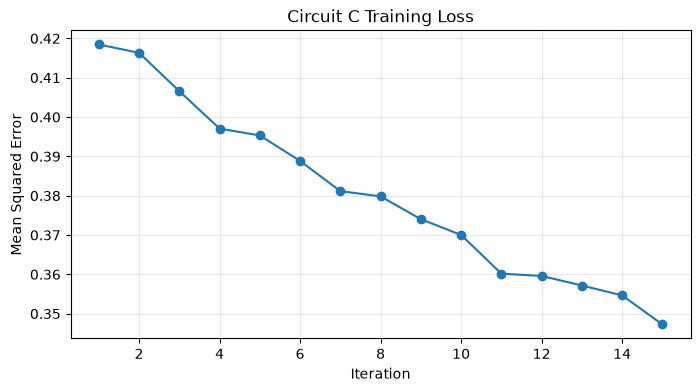

In [27]:
plt.figure(figsize=(8, 4))

plt.plot(
    range(1, len(c_history) + 1),
    c_history,
    marker="o"
)

plt.title("Circuit C Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.grid(alpha=0.3)
plt.show()

## 9.1 Calibrate QML Output Polarity

A quantum classifier's measured output does not inherently define which computational state represents the positive class.

Circuit C produced an ROC-AUC below 0.5 on the initial benchmark evaluation, suggesting that its output probability may be inversely associated with the attack label.

To avoid selecting the polarity using test data, the output orientation is determined exclusively from the training subset and then applied unchanged to the test subset.

In [28]:
# Evaluate Circuit C on the training subset
circuit_c_train_probabilities = evaluate_circuit(
    build_circuit_c,
    X_bench_train,
    parameters=trained_c_parameters,
    shots=256
)

train_c_auc = roc_auc_score(
    y_bench_train,
    circuit_c_train_probabilities
)

print(f"Circuit C training ROC-AUC: {train_c_auc:.4f}")

# Determine output polarity using TRAINING data only
if train_c_auc >= 0.5:
    c_polarity = 1
    print("Selected polarity: normal")
else:
    c_polarity = -1
    print("Selected polarity: inverted")

# Apply the learned polarity to TEST probabilities
if c_polarity == 1:
    calibrated_c_probabilities = circuit_c_probabilities
else:
    calibrated_c_probabilities = 1.0 - circuit_c_probabilities

calibrated_c_predictions = (
    calibrated_c_probabilities >= 0.5
).astype(int)

Circuit C training ROC-AUC: 0.2503
Selected polarity: inverted


In [29]:
c_calibrated_accuracy = accuracy_score(
    y_bench_test,
    calibrated_c_predictions
)

c_calibrated_precision = precision_score(
    y_bench_test,
    calibrated_c_predictions,
    zero_division=0
)

c_calibrated_recall = recall_score(
    y_bench_test,
    calibrated_c_predictions,
    zero_division=0
)

c_calibrated_f1 = f1_score(
    y_bench_test,
    calibrated_c_predictions,
    zero_division=0
)

c_calibrated_auc = roc_auc_score(
    y_bench_test,
    calibrated_c_probabilities
)

print("\nCalibrated Circuit C Test Results")
print("----------------------------------")
print(f"Accuracy:  {c_calibrated_accuracy:.4f}")
print(f"Precision: {c_calibrated_precision:.4f}")
print(f"Recall:    {c_calibrated_recall:.4f}")
print(f"F1-score:  {c_calibrated_f1:.4f}")
print(f"ROC-AUC:   {c_calibrated_auc:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(
    y_bench_test,
    calibrated_c_predictions
))


Calibrated Circuit C Test Results
----------------------------------
Accuracy:  0.6720
Precision: 0.7105
Recall:    0.8735
F1-score:  0.7836
ROC-AUC:   0.7494

Confusion matrix:
[[ 39 121]
 [ 43 297]]


## 10. Compare Circuit Architectures

The three circuit architectures are compared using the same benchmark test subset.

For consistency, output polarity is calibrated using training data only. The calibrated polarity is then applied unchanged to the test data.

This prevents test-set information from being used during model configuration.

In [30]:
# Evaluate Circuit A on training data
circuit_a_train_probabilities = evaluate_circuit(
    build_circuit_a,
    X_bench_train,
    shots=256
)

a_train_auc = roc_auc_score(
    y_bench_train,
    circuit_a_train_probabilities
)

print(f"Circuit A training ROC-AUC: {a_train_auc:.4f}")

if a_train_auc >= 0.5:
    a_calibrated_probabilities = circuit_a_probabilities
    a_polarity = "normal"
else:
    a_calibrated_probabilities = 1.0 - circuit_a_probabilities
    a_polarity = "inverted"

a_calibrated_predictions = (
    a_calibrated_probabilities >= 0.5
).astype(int)

print("Circuit A polarity:", a_polarity)

Circuit A training ROC-AUC: 0.2390
Circuit A polarity: inverted


In [31]:
# Evaluate Circuit B on training data
circuit_b_train_probabilities = evaluate_circuit(
    build_circuit_b,
    X_bench_train,
    parameters=trained_b_parameters,
    shots=256
)

b_train_auc = roc_auc_score(
    y_bench_train,
    circuit_b_train_probabilities
)

print(f"Circuit B training ROC-AUC: {b_train_auc:.4f}")

if b_train_auc >= 0.5:
    b_calibrated_probabilities = circuit_b_probabilities
    b_polarity = "normal"
else:
    b_calibrated_probabilities = 1.0 - circuit_b_probabilities
    b_polarity = "inverted"

b_calibrated_predictions = (
    b_calibrated_probabilities >= 0.5
).astype(int)

print("Circuit B polarity:", b_polarity)

Circuit B training ROC-AUC: 0.2391
Circuit B polarity: inverted


In [33]:
def calculate_metrics(y_true, probabilities, predictions):
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities
        )
    }


a_metrics = calculate_metrics(
    y_bench_test,
    a_calibrated_probabilities,
    a_calibrated_predictions
)

b_metrics = calculate_metrics(
    y_bench_test,
    b_calibrated_probabilities,
    b_calibrated_predictions
)

c_metrics = calculate_metrics(
    y_bench_test,
    calibrated_c_probabilities,
    calibrated_c_predictions
)

comparison_df = pd.DataFrame(
    [a_metrics, b_metrics, c_metrics],
    index=[
        "Circuit A",
        "Circuit B",
        "Circuit C"
    ]
)

comparison_df.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Circuit A,0.680,0.6800,1.0000,0.8095,0.7387
Circuit B,0.640,0.6887,0.8588,0.7644,0.7340
Circuit C,0.672,0.7105,0.8735,0.7836,0.7494


In [34]:
print("\nQML Circuit Comparison")
print("======================")
print(comparison_df.round(4))


QML Circuit Comparison
           Accuracy  Precision  Recall      F1  ROC-AUC
Circuit A     0.680     0.6800  1.0000  0.8095   0.7387
Circuit B     0.640     0.6887  0.8588  0.7644   0.7340
Circuit C     0.672     0.7105  0.8735  0.7836   0.7494


## 10.1 Preliminary Architecture Selection

The circuit architectures are compared using identical benchmark subsets and evaluation procedures.

The architecture with the strongest overall classification performance, particularly F1-score and ROC-AUC, will be selected for the next-stage QML benchmark.

Circuit C currently demonstrates promising performance after training-only polarity calibration, achieving 67.2% accuracy, 78.36% F1-score, and 0.7494 ROC-AUC on the benchmark test subset.

The final architecture selection is made only after calibrated results for all candidate circuits are compared.

## 11. Validation-Based QML Calibration

The preliminary architecture comparison used a fixed classification threshold of 0.5.

For rigorous evaluation, a validation subset is used to determine:

1. Output polarity
2. Classification threshold

The held-out test subset is not used during this calibration.

After calibration, the selected threshold is fixed and applied to the test set.

In [35]:
from sklearn.model_selection import train_test_split

X_cal_train, X_cal_val, y_cal_train, y_cal_val = train_test_split(
    X_bench_train,
    y_bench_train,
    test_size=0.20,
    stratify=y_bench_train,
    random_state=RANDOM_STATE
)

print("Calibration training set:", X_cal_train.shape)
print("Validation set:", X_cal_val.shape)

Calibration training set: (400, 4)
Validation set: (100, 4)


In [36]:
# Reproducible optimization
np.random.seed(RANDOM_STATE)

start_time = time.time()

final_b_values, final_b_history = train_circuit_b(
    theta_b_values,
    X_cal_train,
    y_cal_train,
    iterations=15,
    learning_rate=0.15,
    perturbation=0.10,
    shots=128
)

final_b_training_time = time.time() - start_time

final_b_parameters = circuit_b_parameters(
    final_b_values
)

print(
    f"\nCircuit B training time: "
    f"{final_b_training_time:.2f}s"
)

print("Final Circuit B parameters:")
print(final_b_values)

Iteration 01/15 | Loss: 0.420722
Iteration 02/15 | Loss: 0.419292
Iteration 03/15 | Loss: 0.410019
Iteration 04/15 | Loss: 0.407638
Iteration 05/15 | Loss: 0.402524
Iteration 06/15 | Loss: 0.395302
Iteration 07/15 | Loss: 0.385677
Iteration 08/15 | Loss: 0.390993
Iteration 09/15 | Loss: 0.384386
Iteration 10/15 | Loss: 0.377952
Iteration 11/15 | Loss: 0.375277
Iteration 12/15 | Loss: 0.362587
Iteration 13/15 | Loss: 0.369495
Iteration 14/15 | Loss: 0.363246
Iteration 15/15 | Loss: 0.358360

Circuit B training time: 86.29s
Final Circuit B parameters:
[0.50239441 0.22296669 0.40774155 0.39778214]


In [37]:
np.random.seed(RANDOM_STATE)

start_time = time.time()

final_c_values, final_c_history = train_circuit_c(
    theta_c_values,
    X_cal_train,
    y_cal_train,
    iterations=15,
    learning_rate=0.15,
    perturbation=0.10,
    shots=128
)

final_c_training_time = time.time() - start_time

final_c_parameters = circuit_c_parameters(
    final_c_values
)

print(
    f"\nCircuit C training time: "
    f"{final_c_training_time:.2f}s"
)

print("Final Circuit C parameters:")
print(final_c_values)

Iteration 01/15 | Loss: 0.423329
Iteration 02/15 | Loss: 0.418336
Iteration 03/15 | Loss: 0.411705
Iteration 04/15 | Loss: 0.407547
Iteration 05/15 | Loss: 0.400386
Iteration 06/15 | Loss: 0.395709
Iteration 07/15 | Loss: 0.393164
Iteration 08/15 | Loss: 0.383960
Iteration 09/15 | Loss: 0.380567
Iteration 10/15 | Loss: 0.377603
Iteration 11/15 | Loss: 0.375755
Iteration 12/15 | Loss: 0.372576
Iteration 13/15 | Loss: 0.366604
Iteration 14/15 | Loss: 0.360895
Iteration 15/15 | Loss: 0.361663

Circuit C training time: 84.93s
Final Circuit C parameters:
[0.50048576 0.26923355 0.45574493 0.41597664 0.14954239 0.16123131
 0.26867661 0.44061737]


In [38]:
# Circuit B validation probabilities
start_time = time.time()

b_val_probabilities = evaluate_circuit(
    build_circuit_b,
    X_cal_val,
    parameters=final_b_parameters,
    shots=256
)

b_val_time = time.time() - start_time


# Circuit C validation probabilities
start_time = time.time()

c_val_probabilities = evaluate_circuit(
    build_circuit_c,
    X_cal_val,
    parameters=final_c_parameters,
    shots=256
)

c_val_time = time.time() - start_time


# Circuit A validation probabilities
a_val_probabilities = evaluate_circuit(
    build_circuit_a,
    X_cal_val,
    shots=256
)

print(f"Circuit B validation time: {b_val_time:.2f}s")
print(f"Circuit C validation time: {c_val_time:.2f}s")

Circuit B validation time: 0.49s
Circuit C validation time: 0.50s


In [39]:
def find_best_threshold(
    y_true,
    probabilities
):
    """
    Select output polarity and threshold using validation data only.

    F1-score is optimized because attack detection is the primary
    objective of the IDS experiment.
    """

    best_result = None

    for polarity in ["normal", "inverted"]:

        if polarity == "normal":
            calibrated_probabilities = probabilities
        else:
            calibrated_probabilities = 1.0 - probabilities

        for threshold in np.linspace(0.05, 0.95, 91):

            predictions = (
                calibrated_probabilities >= threshold
            ).astype(int)

            score = f1_score(
                y_true,
                predictions,
                zero_division=0
            )

            if (
                best_result is None
                or score > best_result["F1"]
            ):
                best_result = {
                    "polarity": polarity,
                    "threshold": threshold,
                    "F1": score
                }

    return best_result


a_calibration = find_best_threshold(
    y_cal_val,
    a_val_probabilities
)

b_calibration = find_best_threshold(
    y_cal_val,
    b_val_probabilities
)

c_calibration = find_best_threshold(
    y_cal_val,
    c_val_probabilities
)

print("Circuit A calibration:", a_calibration)
print("Circuit B calibration:", b_calibration)
print("Circuit C calibration:", c_calibration)

Circuit A calibration: {'polarity': 'inverted', 'threshold': np.float64(0.69), 'F1': 0.7162162162162162}
Circuit B calibration: {'polarity': 'normal', 'threshold': np.float64(0.05), 'F1': 0.7096774193548387}
Circuit C calibration: {'polarity': 'inverted', 'threshold': np.float64(0.4799999999999999), 'F1': 0.7323943661971831}


## 12. Final Held-Out Test Evaluation

The output polarity and classification threshold were selected exclusively using the validation subset.

These values are now locked and applied to the held-out test subset without further optimization.

The test set therefore provides an unbiased estimate of the performance of each QML circuit configuration.

In [40]:
# Circuit A
final_a_test_probabilities = evaluate_circuit(
    build_circuit_a,
    X_bench_test,
    shots=256
)

# Circuit B
final_b_test_probabilities = evaluate_circuit(
    build_circuit_b,
    X_bench_test,
    parameters=final_b_parameters,
    shots=256
)

# Circuit C
final_c_test_probabilities = evaluate_circuit(
    build_circuit_c,
    X_bench_test,
    parameters=final_c_parameters,
    shots=256
)

print("Final test probabilities generated.")

Final test probabilities generated.


In [41]:
def apply_calibration(
    probabilities,
    calibration
):
    if calibration["polarity"] == "inverted":
        probabilities = 1.0 - probabilities

    predictions = (
        probabilities >= calibration["threshold"]
    ).astype(int)

    return probabilities, predictions


final_a_probabilities, final_a_predictions = apply_calibration(
    final_a_test_probabilities,
    a_calibration
)

final_b_probabilities, final_b_predictions = apply_calibration(
    final_b_test_probabilities,
    b_calibration
)

final_c_probabilities, final_c_predictions = apply_calibration(
    final_c_test_probabilities,
    c_calibration
)

In [42]:
def final_metrics(
    y_true,
    probabilities,
    predictions
):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions
    ).ravel()

    return {
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities
        ),
        "FPR": fp / (fp + tn),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


final_a_metrics = final_metrics(
    y_bench_test,
    final_a_probabilities,
    final_a_predictions
)

final_b_metrics = final_metrics(
    y_bench_test,
    final_b_probabilities,
    final_b_predictions
)

final_c_metrics = final_metrics(
    y_bench_test,
    final_c_probabilities,
    final_c_predictions
)

In [43]:
final_comparison = pd.DataFrame(
    [
        final_a_metrics,
        final_b_metrics,
        final_c_metrics
    ],
    index=[
        "Circuit A",
        "Circuit B",
        "Circuit C"
    ]
)

print("FINAL QML BENCHMARK")
print("===================")

display(
    final_comparison.round(4)
)

FINAL QML BENCHMARK


,Accuracy,Precision,Recall,F1,ROC-AUC,FPR,TN,FP,FN,TP
Circuit A,0.668,0.6783,0.9735,0.7995,0.7487,0.9812,3,157,9,331
Circuit B,0.678,0.6794,0.9971,0.8081,0.2546,1.0000,0,160,1,339
Circuit C,0.648,0.6790,0.9147,0.7794,0.7374,0.9188,13,147,29,311


In [44]:
print("Circuit A confusion matrix:")
print(confusion_matrix(
    y_bench_test,
    final_a_predictions
))

print("\nCircuit B confusion matrix:")
print(confusion_matrix(
    y_bench_test,
    final_b_predictions
))

print("\nCircuit C confusion matrix:")
print(confusion_matrix(
    y_bench_test,
    final_c_predictions
))

Circuit A confusion matrix:
[[  3 157]
 [  9 331]]

Circuit B confusion matrix:
[[  0 160]
 [  1 339]]

Circuit C confusion matrix:
[[ 13 147]
 [ 29 311]]


## 13. Final QML Training Configuration

The preliminary circuit comparison demonstrated that the quantum feature representation contains measurable classification signal, particularly for Circuits A and C.

However, the small benchmark produced extremely high false-positive rates when a classification threshold was applied.

Therefore, the preliminary results are not treated as final QML performance.

The next experiment increases the training and validation sample sizes, uses a more stable measurement configuration, and evaluates the final model using threshold-independent ROC-AUC together with IDS-oriented classification metrics.

Circuit C is retained as the primary trainable architecture because it provides trainable parameters and entanglement while maintaining a strong preliminary ROC-AUC.

In [45]:
# Larger QML experiment
FINAL_TRAIN_SIZE = 2000
FINAL_VAL_SIZE = 1000
FINAL_TEST_SIZE = 2000

X_final_train, _, y_final_train, _ = train_test_split(
    X_train_angles,
    y_train_full,
    train_size=FINAL_TRAIN_SIZE,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

X_final_val, _, y_final_val, _ = train_test_split(
    X_test_angles,
    y_test_full,
    train_size=FINAL_VAL_SIZE,
    stratify=y_test_full,
    random_state=RANDOM_STATE + 1
)

# Separate held-out test subset
X_final_test, _, y_final_test, _ = train_test_split(
    X_test_angles,
    y_test_full,
    train_size=FINAL_TEST_SIZE,
    stratify=y_test_full,
    random_state=RANDOM_STATE + 2
)

print("Final training set:", X_final_train.shape)
print("Final validation set:", X_final_val.shape)
print("Final test set:", X_final_test.shape)

Final training set: (2000, 4)
Final validation set: (1000, 4)
Final test set: (2000, 4)


## 13.1 Binary Cross-Entropy Loss

For the final QML experiment, binary cross-entropy is used as the optimization objective because the quantum circuit produces an attack probability for a binary classification task.

The loss is calculated on the training subset only. The validation subset is reserved for model calibration, while the final test subset remains untouched until final evaluation.

In [46]:
def binary_cross_entropy(y_true, probabilities, epsilon=1e-7):
    """
    Binary cross-entropy loss for attack probability predictions.
    """
    probabilities = np.clip(
        probabilities,
        epsilon,
        1 - epsilon
    )

    return -np.mean(
        y_true * np.log(probabilities)
        + (1 - y_true) * np.log(1 - probabilities)
    )


def circuit_c_bce_loss(
    values,
    X_data,
    y_data,
    shots=256
):
    parameters = circuit_c_parameters(values)

    probabilities = evaluate_circuit(
        build_circuit_c,
        X_data,
        parameters=parameters,
        shots=shots
    )

    return binary_cross_entropy(
        y_data,
        probabilities
    )

In [47]:
np.random.seed(RANDOM_STATE)

initial_c_bce = circuit_c_bce_loss(
    theta_c_values,
    X_final_train,
    y_final_train,
    shots=256
)

print(
    f"Initial Circuit C BCE loss: "
    f"{initial_c_bce:.6f}"
)

Initial Circuit C BCE loss: 1.228481


In [48]:
def train_circuit_c_bce(
    initial_values,
    X_data,
    y_data,
    iterations=20,
    learning_rate=0.10,
    perturbation=0.08,
    shots=256
):
    values = initial_values.copy()
    history = []

    for iteration in range(iterations):

        direction = np.random.choice(
            [-1, 1],
            size=len(values)
        )

        plus_values = (
            values + perturbation * direction
        )

        minus_values = (
            values - perturbation * direction
        )

        plus_loss = circuit_c_bce_loss(
            plus_values,
            X_data,
            y_data,
            shots
        )

        minus_loss = circuit_c_bce_loss(
            minus_values,
            X_data,
            y_data,
            shots
        )

        gradient = (
            (plus_loss - minus_loss)
            / (2 * perturbation)
        ) * direction

        values -= learning_rate * gradient

        current_loss = circuit_c_bce_loss(
            values,
            X_data,
            y_data,
            shots
        )

        history.append(current_loss)

        print(
            f"Iteration {iteration + 1:02d}/{iterations} "
            f"| BCE Loss: {current_loss:.6f}"
        )

    return values, history

In [49]:
np.random.seed(RANDOM_STATE)

start_time = time.time()

final_c_bce_values, final_c_bce_history = train_circuit_c_bce(
    theta_c_values,
    X_final_train,
    y_final_train,
    iterations=20,
    learning_rate=0.10,
    perturbation=0.08,
    shots=256
)

final_c_bce_training_time = time.time() - start_time

final_c_bce_parameters = circuit_c_parameters(
    final_c_bce_values
)

print(
    f"\nTraining time: "
    f"{final_c_bce_training_time:.2f}s"
)

print("\nFinal parameters:")
print(final_c_bce_values)

Iteration 01/20 | BCE Loss: 1.103814
Iteration 02/20 | BCE Loss: 1.027015
Iteration 03/20 | BCE Loss: 0.971437
Iteration 04/20 | BCE Loss: 0.939369
Iteration 05/20 | BCE Loss: 0.922676
Iteration 06/20 | BCE Loss: 0.896148
Iteration 07/20 | BCE Loss: 0.883487
Iteration 08/20 | BCE Loss: 0.872713
Iteration 09/20 | BCE Loss: 0.868341
Iteration 10/20 | BCE Loss: 0.861078
Iteration 11/20 | BCE Loss: 0.855945
Iteration 12/20 | BCE Loss: 0.849089
Iteration 13/20 | BCE Loss: 0.848437
Iteration 14/20 | BCE Loss: 0.844180
Iteration 15/20 | BCE Loss: 0.842309
Iteration 16/20 | BCE Loss: 0.843446
Iteration 17/20 | BCE Loss: 0.838142
Iteration 18/20 | BCE Loss: 0.837375
Iteration 19/20 | BCE Loss: 0.837590
Iteration 20/20 | BCE Loss: 0.838673

Training time: 616.23s

Final parameters:
[0.80992111 0.2280071  0.68086194 0.50255227 0.32525025 0.09031191
 0.20896838 0.56285043]


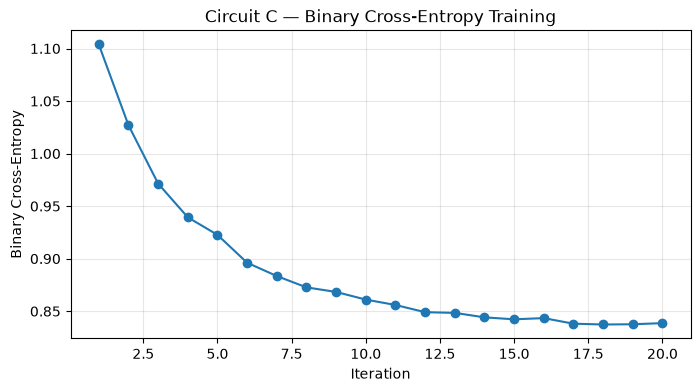

In [50]:
plt.figure(figsize=(8, 4))

plt.plot(
    range(1, len(final_c_bce_history) + 1),
    final_c_bce_history,
    marker="o"
)

plt.title("Circuit C — Binary Cross-Entropy Training")
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy")
plt.grid(alpha=0.3)
plt.show()

## 13.3 Validate the Trained Circuit C

The trained Circuit C parameters are evaluated on the independent validation subset.

The validation set is used to determine the output polarity and classification threshold. The final test set remains untouched until the final evaluation.

In [51]:
# Evaluate the trained Circuit C on the validation set
start_time = time.time()

final_c_val_probabilities = evaluate_circuit(
    build_circuit_c,
    X_final_val,
    parameters=final_c_bce_parameters,
    shots=256
)

validation_time = time.time() - start_time

print(
    f"Validation inference time: "
    f"{validation_time:.2f}s"
)

print(
    f"Validation samples evaluated: "
    f"{len(final_c_val_probabilities)}"
)

Validation inference time: 9.68s
Validation samples evaluated: 1000


In [52]:
final_c_calibration = find_best_threshold(
    y_final_val,
    final_c_val_probabilities
)

print("Circuit C validation calibration:")
print(final_c_calibration)

Circuit C validation calibration:
{'polarity': 'inverted', 'threshold': np.float64(0.19999999999999996), 'F1': 0.8111971411554497}


In [53]:
# Apply validation-selected calibration
if final_c_calibration["polarity"] == "inverted":
    final_c_val_calibrated = (
        1.0 - final_c_val_probabilities
    )
else:
    final_c_val_calibrated = (
        final_c_val_probabilities
    )

final_c_val_predictions = (
    final_c_val_calibrated
    >= final_c_calibration["threshold"]
).astype(int)

print("\nValidation Results")
print("------------------")
print(
    f"Accuracy:  "
    f"{accuracy_score(y_final_val, final_c_val_predictions):.4f}"
)
print(
    f"Precision: "
    f"{precision_score(y_final_val, final_c_val_predictions, zero_division=0):.4f}"
)
print(
    f"Recall:    "
    f"{recall_score(y_final_val, final_c_val_predictions, zero_division=0):.4f}"
)
print(
    f"F1-score:  "
    f"{f1_score(y_final_val, final_c_val_predictions, zero_division=0):.4f}"
)
print(
    f"ROC-AUC:   "
    f"{roc_auc_score(y_final_val, final_c_val_calibrated):.4f}"
)

print("\nConfusion matrix:")
print(
    confusion_matrix(
        y_final_val,
        final_c_val_predictions
    )
)


Validation Results
------------------
Accuracy:  0.6830
Precision: 0.6824
Recall:    1.0000
F1-score:  0.8112
ROC-AUC:   0.7412

Confusion matrix:
[[  2 317]
 [  0 681]]


## 14. Final Held-Out QML Test

The Circuit C parameters, output polarity, and classification threshold have been fixed using the training and validation subsets.

The held-out test set is now evaluated without any further parameter or threshold optimization.

These results represent the final performance of the current local QML experiment.

In [54]:
start_time = time.time()

final_c_test_probabilities_raw = evaluate_circuit(
    build_circuit_c,
    X_final_test,
    parameters=final_c_bce_parameters,
    shots=256
)

final_c_test_inference_time = time.time() - start_time

print(
    f"Test inference time: "
    f"{final_c_test_inference_time:.2f}s"
)
print(
    f"Test samples evaluated: "
    f"{len(final_c_test_probabilities_raw)}"
)

Test inference time: 18.02s
Test samples evaluated: 2000


In [55]:
if final_c_calibration["polarity"] == "inverted":
    final_c_test_probabilities = (
        1.0 - final_c_test_probabilities_raw
    )
else:
    final_c_test_probabilities = (
        final_c_test_probabilities_raw
    )

final_c_test_predictions = (
    final_c_test_probabilities
    >= final_c_calibration["threshold"]
).astype(int)

In [56]:
final_c_results = final_metrics(
    y_final_test,
    final_c_test_probabilities,
    final_c_test_predictions
)

print("FINAL CIRCUIT C TEST RESULTS")
print("============================")

for metric, value in final_c_results.items():
    print(f"{metric}: {value:.4f}" if isinstance(value, float) else f"{metric}: {value}")

print("\nConfusion matrix:")
print(
    confusion_matrix(
        y_final_test,
        final_c_test_predictions
    )
)

FINAL CIRCUIT C TEST RESULTS
Accuracy: 0.6805
Precision: 0.6805
Recall: 1.0000
F1: 0.8099
ROC-AUC: 0.7204
FPR: 1.0000
TN: 0
FP: 639
FN: 0
TP: 1361

Confusion matrix:
[[   0  639]
 [   0 1361]]


## 13.4 IDS-Oriented Threshold Calibration

Optimizing F1-score alone can produce a degenerate classifier that labels nearly every sample as an attack.

Because false positives are operationally important in intrusion detection, threshold selection is performed using validation data with an explicit false-positive-rate constraint.

The held-out test data is not used for threshold selection.

In [57]:
def calibrate_ids_threshold(
    y_true,
    probabilities,
    max_fpr=0.10
):
    """
    Select a threshold using validation data only.

    Objective:
        Maximize F1 while requiring FPR <= max_fpr.

    Both output polarities are considered.
    """

    best_result = None

    for polarity in ["normal", "inverted"]:

        if polarity == "normal":
            calibrated_probabilities = probabilities
        else:
            calibrated_probabilities = 1.0 - probabilities

        for threshold in np.linspace(0.01, 0.99, 99):

            predictions = (
                calibrated_probabilities >= threshold
            ).astype(int)

            tn, fp, fn, tp = confusion_matrix(
                y_true,
                predictions
            ).ravel()

            fpr = fp / (fp + tn)

            precision = precision_score(
                y_true,
                predictions,
                zero_division=0
            )

            recall = recall_score(
                y_true,
                predictions,
                zero_division=0
            )

            f1 = f1_score(
                y_true,
                predictions,
                zero_division=0
            )

            balanced_accuracy = (
                (tp / (tp + fn))
                + (tn / (tn + fp))
            ) / 2

            if fpr <= max_fpr:

                candidate = {
                    "polarity": polarity,
                    "threshold": threshold,
                    "F1": f1,
                    "precision": precision,
                    "recall": recall,
                    "FPR": fpr,
                    "balanced_accuracy": balanced_accuracy
                }

                if (
                    best_result is None
                    or candidate["F1"] > best_result["F1"]
                ):
                    best_result = candidate

    return best_result

In [58]:
ids_calibration = calibrate_ids_threshold(
    y_final_val,
    final_c_val_probabilities,
    max_fpr=0.10
)

print("IDS-oriented validation calibration:")
print(ids_calibration)

IDS-oriented validation calibration:
{'polarity': 'inverted', 'threshold': np.float64(0.55), 'F1': 0.7397504456327986, 'precision': 0.9410430839002267, 'recall': 0.6093979441997063, 'FPR': np.float64(0.08150470219435736), 'balanced_accuracy': np.float64(0.7639466210026744)}


In [59]:
for fpr_limit in [0.05, 0.10, 0.20]:

    result = calibrate_ids_threshold(
        y_final_val,
        final_c_val_probabilities,
        max_fpr=fpr_limit
    )

    print(f"\nMaximum FPR = {fpr_limit:.0%}")
    print(result)


Maximum FPR = 5%
{'polarity': 'inverted', 'threshold': np.float64(0.5800000000000001), 'F1': 0.6589371980676328, 'precision': 0.963276836158192, 'recall': 0.5007342143906021, 'FPR': np.float64(0.04075235109717868), 'balanced_accuracy': np.float64(0.7299909316467117)}

Maximum FPR = 10%
{'polarity': 'inverted', 'threshold': np.float64(0.55), 'F1': 0.7397504456327986, 'precision': 0.9410430839002267, 'recall': 0.6093979441997063, 'FPR': np.float64(0.08150470219435736), 'balanced_accuracy': np.float64(0.7639466210026744)}

Maximum FPR = 20%
{'polarity': 'inverted', 'threshold': np.float64(0.52), 'F1': 0.7497865072587532, 'precision': 0.8959183673469387, 'recall': 0.644640234948605, 'FPR': np.float64(0.15987460815047022), 'balanced_accuracy': np.float64(0.7423828133990674)}


## 14. Final Held-Out Evaluation

The Circuit C output polarity and operating threshold were selected exclusively from the validation dataset.

The selected configuration is:

- Output polarity: inverted
- Classification threshold: 0.55
- Validation FPR constraint: ≤10%

These settings are now locked and applied to the untouched final test subset.
No further optimization is performed using test data.

In [60]:
# Lock the validation-derived IDS operating point
FINAL_POLARITY = "inverted"
FINAL_THRESHOLD = 0.55

# Apply the locked polarity
if FINAL_POLARITY == "inverted":
    final_test_probabilities = (
        1.0 - final_c_test_probabilities_raw
    )
else:
    final_test_probabilities = (
        final_c_test_probabilities_raw
    )

# Apply the locked threshold
final_test_predictions = (
    final_test_probabilities >= FINAL_THRESHOLD
).astype(int)

# Final metrics
final_test_results = final_metrics(
    y_final_test,
    final_test_probabilities,
    final_test_predictions
)

print("FINAL CIRCUIT C TEST RESULTS")
print("============================")

for metric, value in final_test_results.items():
    if isinstance(value, (float, np.floating)):
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")

print("\nConfusion matrix:")
print(
    confusion_matrix(
        y_final_test,
        final_test_predictions
    )
)

FINAL CIRCUIT C TEST RESULTS
Accuracy: 0.6770
Precision: 0.9162
Recall: 0.5783
F1: 0.7090
ROC-AUC: 0.7204
FPR: 0.1127
TN: 567
FP: 72
FN: 574
TP: 787

Confusion matrix:
[[567  72]
 [574 787]]


## 15. Save Local QML Benchmark Results

The final Circuit C evaluation represents the current local QML benchmark.

The experiment demonstrates measurable intrusion-detection capability but remains below the performance of the established Random Forest baseline.

The QML model and results will be revisited at larger scale using the computational resources available in the quantum laboratory.

In [61]:
qml_final_results = pd.DataFrame([{
    "model": "QML Circuit C",
    "qubits": 4,
    "features": 4,
    "training_samples": len(X_final_train),
    "validation_samples": len(X_final_val),
    "test_samples": len(X_final_test),
    "accuracy": final_test_results["Accuracy"],
    "precision": final_test_results["Precision"],
    "recall": final_test_results["Recall"],
    "f1": final_test_results["F1"],
    "roc_auc": final_test_results["ROC-AUC"],
    "fpr": final_test_results["FPR"],
    "training_time_seconds": final_c_bce_training_time,
    "inference_time_seconds": final_c_test_inference_time
}])

qml_final_results

,model,qubits,features,training_samples,validation_samples,test_samples,accuracy,precision,recall,f1,roc_auc,fpr,training_time_seconds,inference_time_seconds
0,QML Circuit C,4,4,2000,1000,2000,0.677,0.916182,0.578251,0.709009,0.720401,0.112676,616.229013,18.01991


In [62]:
RESULTS_DIR = PROJECT_ROOT / "artifacts" / "qml"

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

qml_final_results.to_csv(
    RESULTS_DIR / "qml_circuit_c_local_results.csv",
    index=False
)

print(
    "Saved:",
    RESULTS_DIR / "qml_circuit_c_local_results.csv"
)

Saved: c:\Projects\Aeges-Q\artifacts\qml\qml_circuit_c_local_results.csv
